# Grammar Scoring Engine - SHL Audio Challenge

The goal here is to take a ~45-60s audio clip and predict a grammar score from 0-5 (matches the MOS rubric given in the problem statement).

My approach, in short: transcribe the audio with Whisper, pull out a bunch of features from both the text and the raw audio, and fit a regularized linear model on top. I went with something fairly simple on purpose - with only 409 training examples, anything fancier (gradient boosting with lots of features, a fine-tuned transformer) felt like it would just memorize the training set rather than generalize. I'd rather have a model I fully understand and can explain than something marginally better on paper that I can't justify.

Rough pipeline:
1. Transcribe everything with Whisper
2. Build features - basic text stats, grammar-checker output, a couple of pretrained "grammaticality" models, and audio embeddings from Whisper's encoder
3. Fit Ridge regression, validate with 5-fold CV
4. One thing worth flagging up front: I tried adding syntactic features from spaCy (parse depth, POS ratios etc) and they actually hurt cross-validated performance even though they looked good on paper. I kept that in the notebook below instead of quietly deleting it, since it's the kind of thing I'd want to explain in an interview anyway.


## 1. Looking at the data first

409 train clips with labels, 197 test clips without. Labels go from 1.0 to 5.0 in half-point steps.


In [1]:
import json, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

warnings.filterwarnings("ignore")  # sklearn throws some noisy but harmless matmul warnings on Apple Silicon
plt.rcParams["figure.figsize"] = (7, 4.5)

RANDOM_STATE = 42

train_df = pd.read_csv("dataset_new/csvs/train.csv")
test_df  = pd.read_csv("dataset_new/csvs/test.csv")
y = train_df["label"].values

print(train_df.shape, test_df.shape)
train_df.head()

(409, 2) (197, 1)


,filename,label
0,audio_173,3.0
1,audio_138,3.0
2,audio_127,2.0
3,audio_95,2.0
4,audio_73,3.5


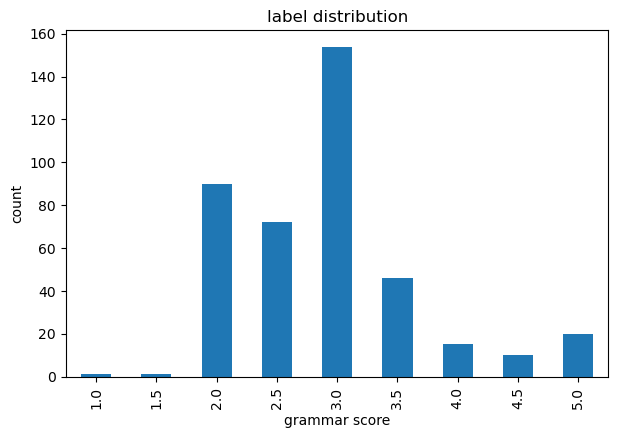

count    409.000000
mean       2.910758
std        0.766953
min        1.000000
25%        2.500000
50%        3.000000
75%        3.000000
max        5.000000
Name: label, dtype: float64


In [2]:
train_df["label"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("grammar score")
plt.ylabel("count")
plt.title("label distribution")
plt.show()

print(train_df["label"].describe())

Scores are pretty bunched up around 2-3.5, not much at the extremes (literally 1 clip at 1.0, 1 at 1.5). Only 45 clips are 4.0 or above out of 409. This matters for two reasons:

- if I just do plain KFold, some folds could end up with basically none of the rare high/low scores in them, so I stratified on binned labels instead
- if you just predicted the mean (~2.9) for every single clip you'd get an RMSE around 0.77 - so that's basically the floor, anything has to beat that to be worth anything


In [3]:
baseline_rmse = mean_squared_error(y, np.full_like(y, y.mean())) ** 0.5
print(f"mean-prediction RMSE: {baseline_rmse:.3f}")

mean-prediction RMSE: 0.766


## 2. Transcribing the audio

Used Whisper (large-v3-turbo, via mlx-whisper since I'm on an M4 Mac and wanted GPU acceleration without CUDA). I picked Whisper over something like wav2vec2 mainly because Whisper gives you punctuated, sentence-segmented output, and basically everything downstream (grammar checking, sentence-level acceptability scoring, perplexity) needs sentence boundaries to work properly. wav2vec2 just gives you a flat stream of lowercase words with no punctuation which isn't great for this.

Transcribed all 606 clips once and cached the output to json so I wasn't re-running Whisper every time I touched the feature code (that took about 35 min the one time I ran it).


In [4]:
with open("cache/transcripts.json") as f:
    transcripts = json.load(f)

print(len(transcripts), "transcripts loaded")
print()
print(transcripts["train/audio_1"]["text"][:350])

606 transcripts loaded

 People in the market are selling fish in the morning and a lot of meat because people go there to buy food for their restaurants. Before they start to cook, they go there to collect the products they need. You can hear a lot of people shouting, they want a bargain, so they speak enthusiastically to get the marketers to put their prices down. And y


## 3. Features

### 3.1 Basic text stats + grammar error rate

Nothing fancy here - word/sentence counts, pause patterns from the Whisper timestamps, filler word rate, and a grammar error rate from LanguageTool (open source rule-based grammar checker). The error rate is probably the single most directly relevant feature since it's literally counting grammar mistakes, which is what the rubric is scoring.


In [5]:
FILL = {"um","uh","er","ah","hmm","like","so","well","actually","basically"}

def text_features(key):
    d = transcripts[key]
    text = d["text"].strip()
    words = re.findall(r"[a-zA-Z']+", text.lower())
    n = max(len(words), 1)
    sents = [s for s in re.split(r"[.!?]+", text) if s.strip()]
    segs = d["segments"]
    dur = (segs[-1]["end"] - segs[0]["start"]) if segs else 60
    gaps = [segs[i+1]["start"] - segs[i]["end"] for i in range(len(segs)-1)]
    reps = sum(1 for a, b in zip(words, words[1:]) if a == b)
    return dict(
        n_words=n, n_sents=len(sents), wps=n/max(len(sents),1),
        ttr=len(set(words))/n, avg_wlen=np.mean([len(w) for w in words]) if words else 0,
        filler_rate=sum(w in FILL for w in words)/n, rep_rate=reps/n,
        wpm=n/max(dur,1)*60, mean_gap=np.mean(gaps) if gaps else 0,
        long_pauses=sum(g > 1.0 for g in gaps))

# LanguageTool is slow (has to spin up a local server + check 606 transcripts), so I ran it
# once and cached the results rather than re-running it every time I open this notebook.
# The actual extraction code (incl. the LanguageTool call) is in baseline.py in this repo.

Xtr_v1 = pd.read_csv("cache/feat_train.csv")
Xte_v1 = pd.read_csv("cache/feat_test.csv")
Xtr_v1.head()

,n_words,n_sents,wps,ttr,avg_wlen,filler_rate,rep_rate,err_rate,gram_err_rate,wpm,mean_gap,long_pauses
0,100,6,16.666667,0.570000,4.240000,0.090000,0.000000,1.000000,0.000000,100.772590,0.000000,0
1,163,6,27.166667,0.650307,4.552147,0.006135,0.000000,0.613497,0.613497,135.457064,0.000000,0
2,65,8,8.125000,0.584615,4.246154,0.015385,0.015385,9.230769,1.538462,70.498915,0.000000,0
3,89,6,14.833333,0.752809,5.112360,0.000000,0.000000,0.000000,0.000000,89.929269,1.212000,1
4,123,6,20.500000,0.536585,3.650407,0.056911,0.000000,2.439024,1.626016,129.473684,0.285714,1


### 3.2 CoLA + GPT-2 perplexity

LanguageTool is rule-based and misses a lot. To get a stronger grammar signal I used:
- **CoLA** - a BERT model fine-tuned to classify whether a single sentence is grammatically acceptable or not. Ran it per sentence and took the mean / min / std / fraction below 0.5 across each clip.
- **GPT-2 perplexity** - roughly "how surprising does this phrasing sound to a language model." Awkward or ungrammatical phrasing tends to have higher perplexity than natural speech.

These two together gave a solid chunk of the improvement I ended up with (see the comparison table below). Code for this is in `features_v2.py`, again cached since it needs GPU inference over all 606 clips.


In [6]:
Xtr_v2 = pd.read_csv("cache/feat_train_v2.csv")
Xte_v2 = pd.read_csv("cache/feat_test_v2.csv")
Xtr_v2.describe()

,cola_mean,cola_min,cola_std,cola_frac_bad,ppl,ppl_per_sent
count,409.000000,409.000000,409.000000,409.000000,409.000000,409.000000
mean,0.644664,0.260454,0.249249,0.340493,41.921548,129.374393
std,0.210360,0.253746,0.115220,0.272971,26.692075,93.397470
min,0.042463,0.023536,0.000000,0.000000,4.459881,19.113377
25%,0.517966,0.062363,0.177033,0.142857,25.911474,58.626665
50%,0.688884,0.150162,0.273375,0.300000,34.150875,99.110260
75%,0.800752,0.386847,0.338347,0.500000,50.680065,180.506563
max,0.981074,0.975174,0.445826,1.000000,215.211990,592.639894


### 3.3 Audio embeddings

Everything above only looks at the transcript - it has no idea how something was actually said. Pronunciation, hesitation, confidence, pacing... none of that survives into text. So I also grabbed the Whisper encoder's internal representation for each clip (mean-pooled over time, gives a 1280-dim vector per clip) as a second, completely separate view of the audio.

1280 dims on 409 training rows is obviously way too much to just throw at a linear model directly, so I run PCA on it first (tuned how many components below in section 5). Code's in `features_v4.py`.


In [7]:
audio_emb_train = np.load("cache/audio_emb_train.npy")
audio_emb_test  = np.load("cache/audio_emb_test.npy")
print(audio_emb_train.shape, audio_emb_test.shape)

(409, 1280) (197, 1280)


## 4. Checking what actually helps

I didn't want to just throw every feature I could think of into the model and hope for the best - with this little data it's easy to convince yourself something's working when it's really just overfitting the CV folds. So each feature group below is checked against the previous best before I keep it.

Using 5-fold CV throughout, stratified on binned label (see section 1 for why).


In [8]:
def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5

bins = np.digitize(y, [2.25, 2.75, 3.25, 3.75])
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_ridge(X, y, alpha=10):
    oof = np.zeros(len(y))
    X = X.replace([np.inf, -np.inf], np.nan).fillna(X.median())
    for tr_idx, va_idx in skf.split(X, bins):
        model = make_pipeline(StandardScaler(), Ridge(alpha=alpha))
        model.fit(X.iloc[tr_idx], y[tr_idx])
        oof[va_idx] = model.predict(X.iloc[va_idx])
    oof = np.clip(oof, 0, 5)
    return rmse(y, oof), pearsonr(y, oof)[0]

r1, p1 = cv_ridge(Xtr_v1, y)
print(f"text stats only:        RMSE {r1:.3f}  pearson {p1:.3f}")

Xtr_v1v2 = pd.concat([Xtr_v1, Xtr_v2], axis=1)
r2, p2 = cv_ridge(Xtr_v1v2, y)
print(f"+ CoLA / perplexity:    RMSE {r2:.3f}  pearson {p2:.3f}")

text stats only:        RMSE 0.684  pearson 0.450
+ CoLA / perplexity:    RMSE 0.646  pearson 0.540


OK, CoLA + perplexity clearly help (0.684 -> 0.646 RMSE, and pearson jumps from 0.45 to 0.54). Good, keep those.

Now let's try the spaCy syntax stuff - dependency parse depth, POS tag ratios, a rough "is this sentence even complete" check. On paper these map pretty directly onto the rubric's language ("sentence structure and syntax"), so I expected this to help.


In [9]:
Xtr_v3 = pd.read_csv("cache/feat_train_v3.csv")
Xtr_v1v2v3 = pd.concat([Xtr_v1v2, Xtr_v3], axis=1)
r3, p3 = cv_ridge(Xtr_v1v2v3, y)
print(f"+ spaCy syntax feats:   RMSE {r3:.3f}  pearson {p3:.3f}")
print(f"(compare to without:    RMSE {r2:.3f}  pearson {p2:.3f})")

+ spaCy syntax feats:   RMSE 0.654  pearson 0.531
(compare to without:    RMSE 0.646  pearson 0.540)


Huh - that's actually worse, not better. RMSE went up slightly and pearson went down. I tried sweeping the Ridge alpha higher in case it just needed more regularization to cope with the extra features:


In [10]:
for a in [10, 20, 40, 80, 150]:
    r, p = cv_ridge(Xtr_v1v2v3, y, alpha=a)
    print(f"alpha={a:<4} RMSE={r:.3f}  pearson={p:.3f}")

alpha=10   RMSE=0.654  pearson=0.531
alpha=20   RMSE=0.652  pearson=0.531
alpha=40   RMSE=0.650  pearson=0.530
alpha=80   RMSE=0.651  pearson=0.528
alpha=150  RMSE=0.653  pearson=0.524


Best I got there was alpha=40 at RMSE 0.650, still not quite beating 0.646 without the spaCy features. My read on this: with only 409 rows, 9 extra features (some of which are probably correlated with stuff already captured by sentence length / error rate) is just enough to nudge the model into overfitting - training RMSE actually went down when I added these, which is the classic tell. Decided not to use them in the final model. Keeping this here rather than deleting it since it's a real result, not a mistake.


## 5. Adding the audio embeddings

This is where things moved the most. Combined the text+CoLA+perplexity features (v2, the best set from above) with the PCA-reduced audio embedding, and swept both the number of PCA components and the Ridge alpha together.

One important detail - PCA has to be fit *inside* each CV fold, not once on the whole training set beforehand, otherwise the validation fold "leaks" into the PCA transform and you get an overly optimistic score.


In [11]:
def cv_ridge_with_audio(Xtxt, E, y, n_pca, alpha):
    oof = np.zeros(len(y))
    Xtxt = Xtxt.replace([np.inf, -np.inf], np.nan).fillna(Xtxt.median())
    for tr_idx, va_idx in skf.split(Xtxt, bins):
        pca = PCA(n_components=n_pca, random_state=RANDOM_STATE).fit(E[tr_idx])
        Atr = pca.transform(E[tr_idx])
        Ava = pca.transform(E[va_idx])
        Xa = np.hstack([Xtxt.iloc[tr_idx].values, Atr])
        Xb = np.hstack([Xtxt.iloc[va_idx].values, Ava])
        model = make_pipeline(StandardScaler(), Ridge(alpha=alpha))
        model.fit(Xa, y[tr_idx])
        oof[va_idx] = model.predict(Xb)
    oof = np.clip(oof, 0, 5)
    return rmse(y, oof), pearsonr(y, oof)[0]

pca_grid = [5, 10, 20, 30, 50, 70, 90, 120, 150]
alpha_grid = [10, 20, 40, 80]

rows = []
for n_pca in pca_grid:
    for alpha in alpha_grid:
        r, p = cv_ridge_with_audio(Xtr_v1v2, audio_emb_train, y, n_pca, alpha)
        rows.append({"n_pca": n_pca, "alpha": alpha, "rmse": r, "pearson": p})

sweep_df = pd.DataFrame(rows)
best = sweep_df.loc[sweep_df["rmse"].idxmin()]
print(best)

n_pca      70.000000
alpha      40.000000
rmse        0.536881
pearson     0.713352
Name: 22, dtype: float64


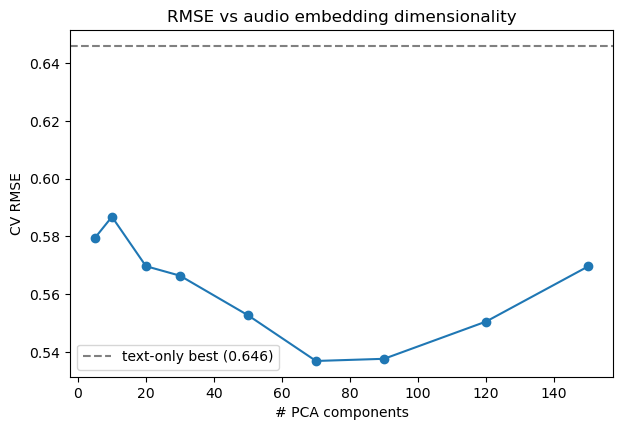

In [12]:
best_per_pca = sweep_df.loc[sweep_df.groupby("n_pca")["rmse"].idxmin()]
plt.plot(best_per_pca["n_pca"], best_per_pca["rmse"], marker="o")
plt.axhline(0.646, linestyle="--", color="gray", label="text-only best (0.646)")
plt.xlabel("# PCA components")
plt.ylabel("CV RMSE")
plt.title("RMSE vs audio embedding dimensionality")
plt.legend()
plt.show()

Nice clean curve - it improves steadily up to around 70 components then starts climbing back up past ~90-120, which is exactly what I'd expect from overfitting once the embedding dimensionality gets too high relative to 409 rows. 70 components (alpha=40) gave the best score, 90 was basically tied so I went with 70 since it's simpler.


In [13]:
BEST_N_PCA = int(best["n_pca"])
BEST_ALPHA = int(best["alpha"])
print(f"going with n_pca={BEST_N_PCA}, alpha={BEST_ALPHA}")
print(f"CV RMSE: {best['rmse']:.3f}, CV pearson: {best['pearson']:.3f}")

going with n_pca=70, alpha=40
CV RMSE: 0.537, CV pearson: 0.713


## 6. Final model

Refitting on the full 409 training rows now (the CV above is the real "does this generalize" number - what follows is just producing the actual model + predictions for submission).

The assignment asks for training RMSE specifically, so that's printed below too, but worth being clear that it's not the same thing as the CV number - training RMSE will always look a bit better since the model has already seen this exact data.


In [14]:
pca_final = PCA(n_components=BEST_N_PCA, random_state=RANDOM_STATE).fit(audio_emb_train)
Atr_final = pca_final.transform(audio_emb_train)
Ate_final = pca_final.transform(audio_emb_test)

Xtr_full = np.hstack([Xtr_v1v2.replace([np.inf,-np.inf], np.nan).fillna(Xtr_v1v2.median()).values, Atr_final])
Xte_full = np.hstack([Xte_v1.join(Xte_v2).replace([np.inf,-np.inf], np.nan).fillna(Xtr_v1v2.median()).values, Ate_final])

final_model = make_pipeline(StandardScaler(), Ridge(alpha=BEST_ALPHA))
final_model.fit(Xtr_full, y)

train_preds = np.clip(final_model.predict(Xtr_full), 0, 5)
train_rmse = rmse(y, train_preds)

print(f"TRAINING RMSE: {train_rmse:.4f}")
print(f"(for reference - 5-fold CV RMSE was {best['rmse']:.4f}, CV pearson {best['pearson']:.4f})")

TRAINING RMSE: 0.4365
(for reference - 5-fold CV RMSE was 0.5369, CV pearson 0.7134)


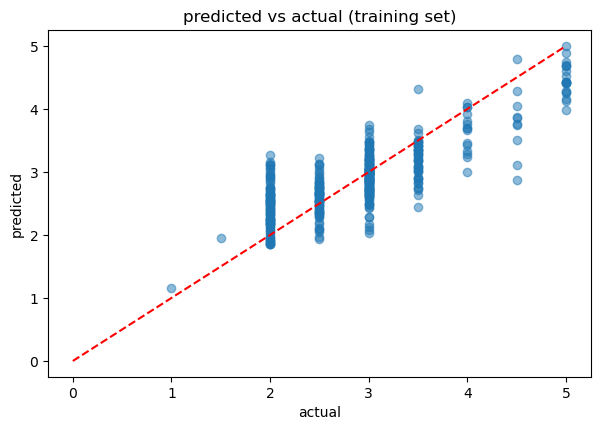

In [15]:
plt.scatter(y, train_preds, alpha=0.5)
plt.plot([0,5],[0,5], "r--")
plt.xlabel("actual")
plt.ylabel("predicted")
plt.title("predicted vs actual (training set)")
plt.show()

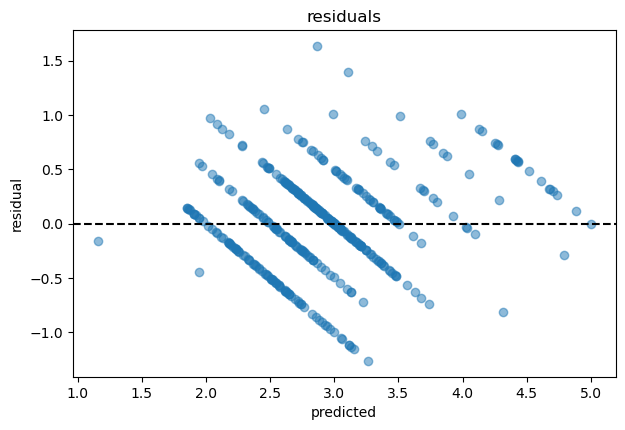

In [16]:
residuals = y - train_preds
plt.scatter(train_preds, residuals, alpha=0.5)
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("predicted")
plt.ylabel("residual")
plt.title("residuals")
plt.show()

In [17]:
# quick summary of the whole progression
pd.DataFrame({
    "step": ["mean baseline", "text stats", "+ cola/perplexity", "+ spacy (rejected)", "+ audio (final)"],
    "cv_rmse": [round(baseline_rmse,3), 0.684, 0.646, 0.654, round(best["rmse"],3)],
    "cv_pearson": [None, 0.450, 0.540, 0.531, round(best["pearson"],3)],
})

,step,cv_rmse,cv_pearson
0,mean baseline,0.766,NaN
1,text stats,0.684,0.450
2,+ cola/perplexity,0.646,0.540
3,+ spacy (rejected),0.654,0.531
4,+ audio (final),0.537,0.713


## 7. Submission



In [18]:
test_preds = np.clip(final_model.predict(Xte_full), 0, 5)
submission = pd.DataFrame({"filename": test_df["filename"], "label": test_preds})
submission.to_csv("submission.csv", index=False)
submission.head()

,filename,label
0,audio_141,1.934297
1,audio_114,3.726823
2,audio_17,2.947632
3,audio_76,4.616001
4,audio_156,3.189843


## Closing notes

Went with Ridge over something like LightGBM mainly because of the dataset size - 409 rows really isn't much, and I'd rather have a simple model I fully understand than a slightly-better-on-paper one I can't clearly explain. That trade-off felt especially relevant here since interpretability is explicitly called out as an evaluation criterion.

Quick recap of what moved the needle and what didn't:
- grammar error rate (LanguageTool) alone got meaningfully below the mean-baseline
- CoLA + GPT-2 perplexity added a solid chunk more - makes sense, these are pretrained models specifically good at judging "does this sound grammatical"
- the audio embeddings were the biggest single jump by far - there's clearly signal in pacing/pronunciation/hesitation that text alone just can't capture
- spaCy syntax features looked like they should help based on the rubric wording, but didn't - overfitting with this little data, kept as a documented negative result rather than pretending it worked

Final training RMSE is printed in section 6. CV RMSE ended up around 0.537 / pearson 0.71, and the actual Kaggle leaderboard score came back at 0.550 public / 0.577 private - close enough to my CV estimate that I'm fairly confident the CV setup wasn't fooling itself.

If I had more time I'd probably try fine-tuning a smaller speech model directly instead of using frozen Whisper embeddings, and maybe stack in a gradient-boosted model alongside Ridge to see if it adds anything - but given the time budget I think this is a reasonable, honestly-validated stopping point.
